In [1]:
import sys, os, torch, pdb
import numpy as np
import torch.nn as nn
from IPython.display import Image

sys.path.append('../../')
sys.path.append('../../../')
cwd = os.getcwd()

from Modules.helpers.performance.density.plotting_loss_running_min import plot_running_min_val_loss_broken_x_log_lst
from Modules.helpers.performance.density.plotting_final_loss import plot_final_loss_lst
from Modules.helpers.performance.plotting_timings import plot_total_run_times_lst

from Modules.helpers.performance.diffusion.plotting_mse_running_min import plot_running_min_MSE_diff_loss_broken_x_log_lst
from Modules.helpers.performance.diffusion.plotting_final_mse import plot_diff_mse_lst
from Modules.helpers.performance.diffusion.gif_model_loss import  save_gif_running_min_MSE_diff_loss_broken_x_log

from Modules.helpers.performance.growth.plotting_mse_running_min_growth import plot_running_min_MSE_grow_loss_broken_x_log_lst
from Modules.helpers.performance.growth.plot_final_mse_grow import plot_grow_mse_lst
from Modules.helpers.performance.growth.gif_model_loss_growth import  save_gif_running_min_MSE_grow_loss_broken_x_log

from Modules.helpers.real_space_plotter import symbolic_from_function, plot_eval_D_multi, plot_eval_G_multi
from Modules.helpers.performance.gif_DG_over_epochs import save_gif_running_min_MSE_diff_and_grow_broken_x_log


from Modules.helpers.plotting_profiles import plot_initial_condition_2d, plot_eval2
from file_finder import (paths_to_df,
                         find_data_obj_files, 
                         condense_df,
                         print_path_components)
from Modules.helpers.parse import dictToPath


# Add to main
from data.python.Modules.dataClass import OriginalData, Data
from binn.python.Modules.Models.BuildBINNs_2D import BINN_2d,u_MLP, D_MLP, G_MLP, pde_loss_without_bc_2d, data_loss_MSE, generate_random_inputs_2d
from binn.python.Modules.Utils.ModelWrapper import ModelWrapper
from binn.python.Modules.Utils.PDESolver_2D import PDE_sim_old_2d_upd, PDE_RHS_2D


ext  = "dataObj/original?_1/DValue_0.024720000000000002/rValue_1.536/gamma_0.2/K_1700.0/xNum_38/tNum_5/originalDataObj.npy"
data_orig_obj_FKPP = np.load(os.path.join('../../../', ext),allow_pickle=True).item(0)


MODULE| `BuildBINN_2D`| version = 11 Sep 25.

Info:
- Version specific to `BINNs_comparison`.
- Contains 'Delay' MLP to be consistent with Lagergren et al. (2020).
- Sufficient module documentation.



In [2]:
x = data_orig_obj_FKPP.x
t = data_orig_obj_FKPP.t
K = 1
inital_path = os.path.join('../../../', "DataObj")

# ==================== Display available data objects ====================
data_df = paths_to_df(find_data_obj_files(start_dir = inital_path,
                                           target_filename="data_obj.npy"))

data_df 

,full_path,dataX1num,dataX2num,dataTnum,dataK,dataICLabel,dataDiffLabel,dataGrowLabel,dataGamma,dataNoisePercent,dataNoiseSeed,data
0,../../../DataObj/dataX1num_21/dataX2num_21/dat...,21,21,9,1,cos,const,linear,0,0,0,obj.npy
1,../../../DataObj/dataX1num_11/dataX2num_11/dat...,11,11,9,1,cos,const,linear,0,0,0,obj.npy
2,../../../DataObj/dataX1num_24/dataX2num_24/dat...,24,24,9,1,cos,const,linear,0,0,0,obj.npy
3,../../../DataObj/dataX1num_12/dataX2num_12/dat...,12,12,5,1,cos,const,exp,0,0,0,obj.npy
4,../../../DataObj/dataX1num_12/dataX2num_12/dat...,12,12,10,1,cos,const,linear,0,0,0,obj.npy
5,../../../DataObj/dataX1num_12/dataX2num_12/dat...,12,12,9,1,cos,const,linear,0,0,0,obj.npy
6,../../../DataObj/dataX1num_12/dataX2num_12/dat...,12,12,9,1,cos,const,linear,0,10,0,obj.npy
7,../../../DataObj/dataX1num_12/dataX2num_12/dat...,12,12,9,1,cos,const,zero,0,10,0,obj.npy
8,../../../DataObj/dataX1num_15/dataX2num_11/dat...,15,11,5,1,cos,const,zero,0,0,0,obj.npy


In [3]:
x1Num = 21
x2Num = 21
tNum = 9
gamma = 0
IC_label = "cos"
diff_label= "const"
seed = 0
results_dict = {}
data_info_dic = {}
noise_percent= 0

grow_labels = ["linear"]#, "quadratic", "exp"]

data_obj_dic = {}
for xNum in [11, 21]:
    data_obj_dic[xNum] = {}
    for grow_label in grow_labels:
        # =================== Choose data object ====================
        data_info = {
                "dataX1num": xNum,
                "dataX2num": xNum,
                "dataTnum": tNum,
                "dataK": K,
                "dataICLabel": IC_label,
                "dataDiffLabel": diff_label,
                "dataGrowLabel": grow_label,
                "dataGamma": gamma,
                "dataNoisePercent": noise_percent,
                "dataNoiseSeed": seed
            }
        data_df_updated = condense_df(data_df, data_info)
        data_file_path = data_df_updated["full_path"][0]
        data_obj = np.load(data_file_path, allow_pickle=True).item()
        data_obj_dic[xNum][grow_label] = data_obj

In [4]:
data_obj_dic[21]["linear"].x2

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [5]:
x1 = np.linspace(0,1,11)
x2 = np.linspace(0,1,21)[::2]
x2

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

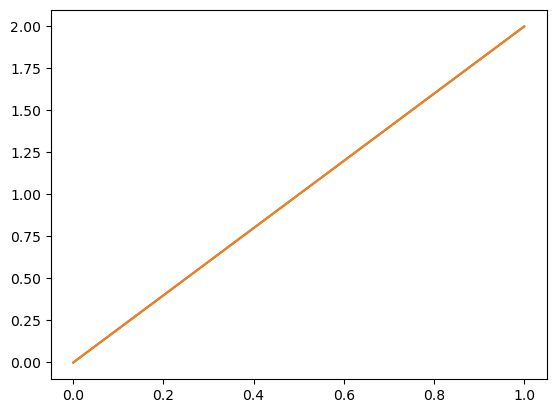

In [6]:
import matplotlib.pyplot as plt
plt.plot(np.linspace(0,1,11), np.linspace(0,1,11)*2)
plt.plot(np.linspace(0,1,21)[::2], np.linspace(0,1,21)[::2]*2)

0.0
0.0


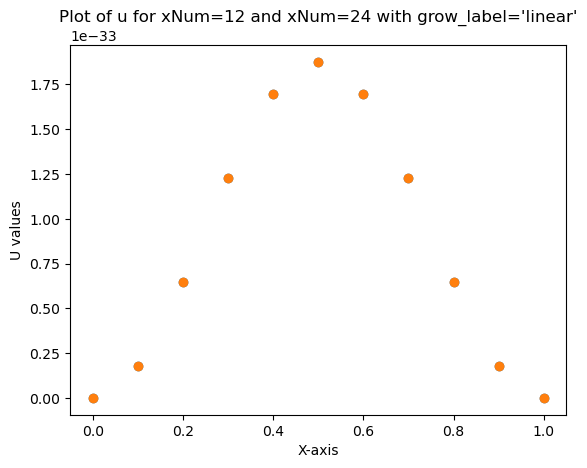

0.1
0.1


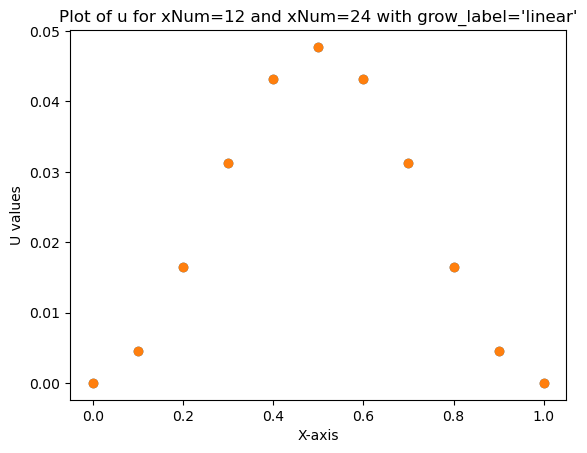

0.2
0.2


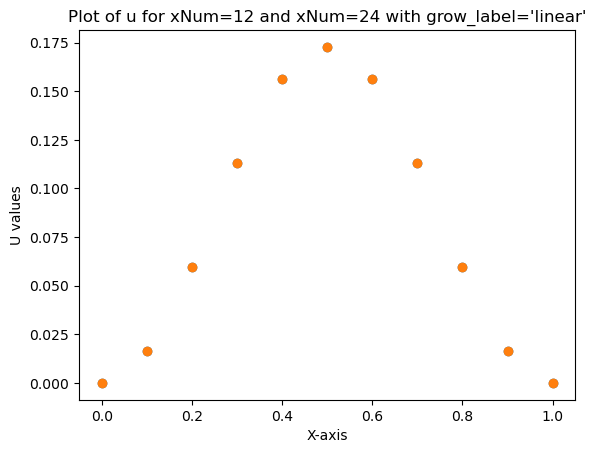

0.30000000000000004
0.30000000000000004


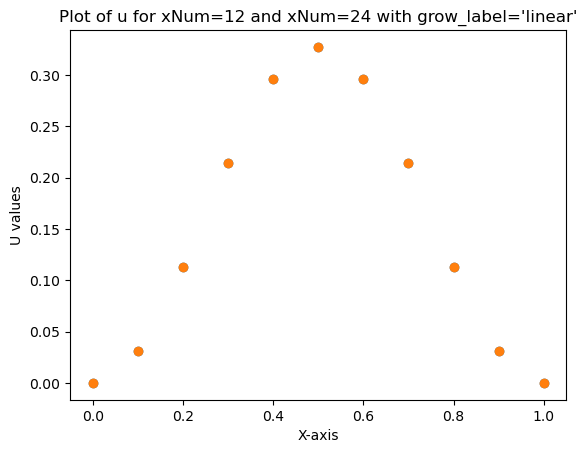

0.4
0.4


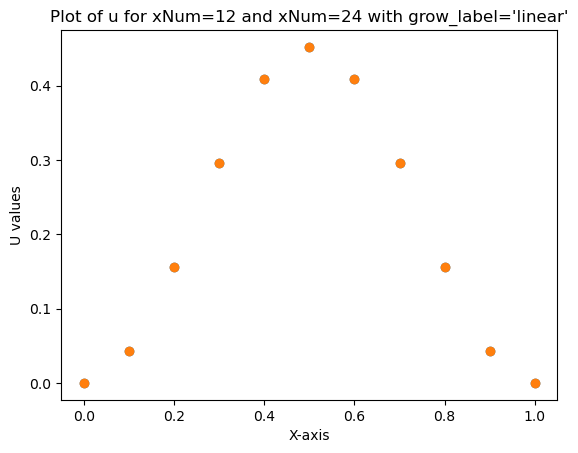

0.5
0.5


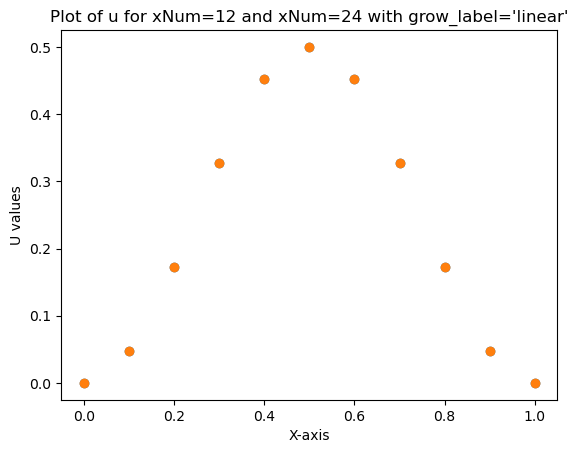

0.6000000000000001
0.6000000000000001


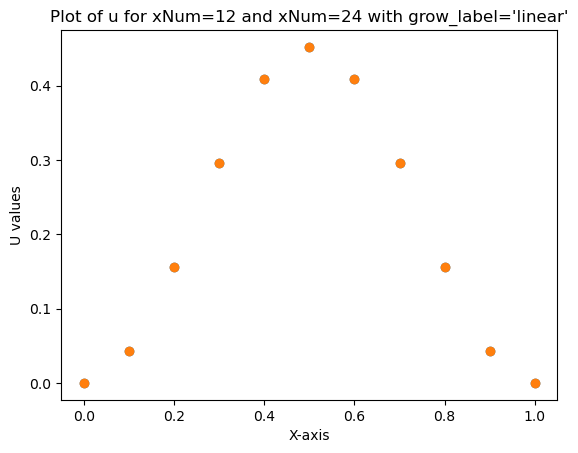

0.7000000000000001
0.7000000000000001


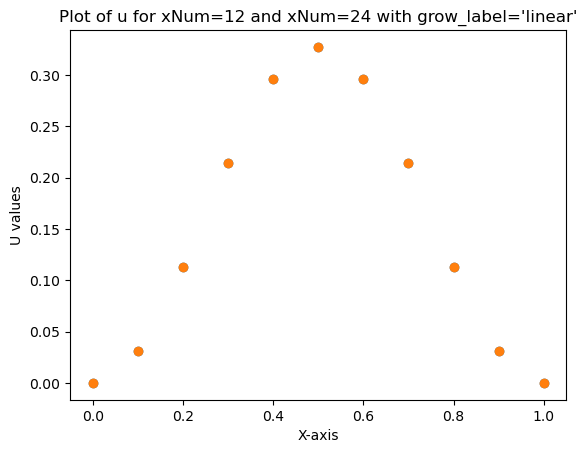

0.8
0.8


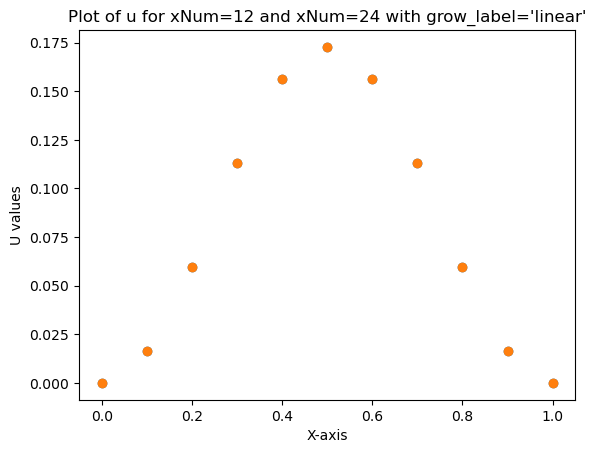

0.9
0.9


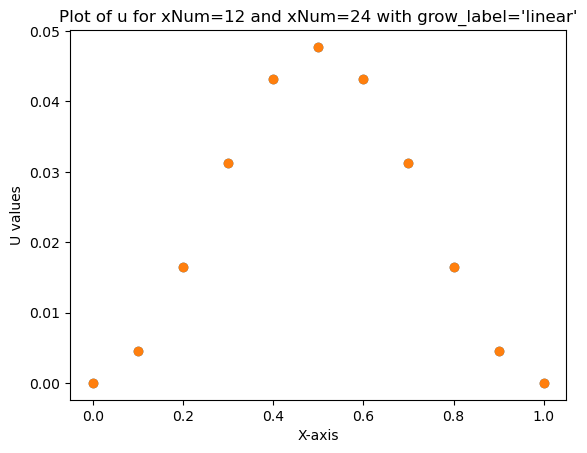

1.0
1.0


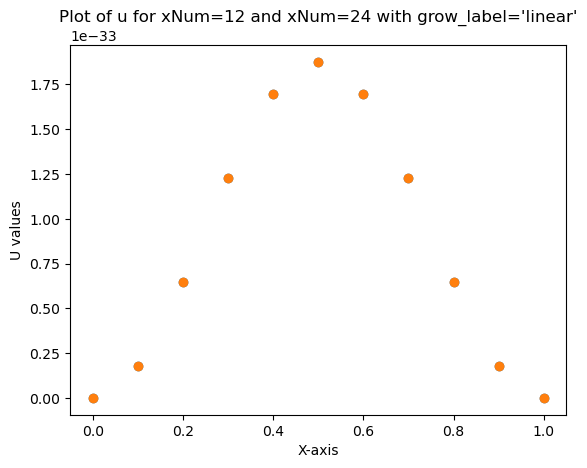

In [7]:
import matplotlib.pyplot as plt

for i in range(len(data_obj_dic[11]["linear"].x2)):
    d1 = data_obj_dic[11]["linear"]
    d1_u = d1.u[:,i,0]
    d2 = data_obj_dic[21]["linear"]
    d2_u = d2.u[:,2*i,0][::2]
    d2_x1 = d2.x1[::2]
    plt.plot(d1.x1, d1_u, label='xNum=12', marker='o', lw=0)
    print(d1.x2[i])
    print(d2.x2[2*i])
    plt.plot(d2_x1, d2_u, label='xNum=24', marker='o', lw=0)
    plt.title("Plot of u for xNum=12 and xNum=24 with grow_label='linear'")
    plt.xlabel("X-axis")
    plt.ylabel("U values")
    plt.show()

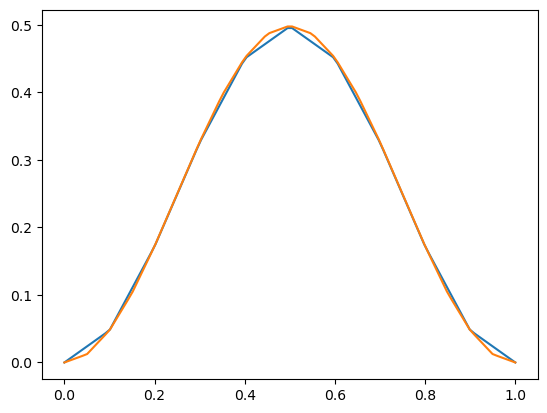

In [ ]:
from scipy.interpolate import RegularGridInterpolator
import itertools
def initialize_simulation(t, x1, x2, IC, numtsim, numxsim1, numxsim2):
    """Initialize simulation grids and interpolate initial conditions."""
    t_sim = np.linspace(np.min(t), np.max(t), numtsim)
    x1_sim = np.linspace(np.min(x1), np.max(x1), numxsim1)
    x2_sim = np.linspace(np.min(x2), np.max(x2), numxsim2)

    f_interpolate = RegularGridInterpolator((x1, x2), IC)
    #print("Interpolating initial conditions...")
    queries_sim = (np.array(list(itertools.product(x1_sim, x2_sim))))
    y0 = f_interpolate(queries_sim).flatten()
    return t_sim, x1_sim, x2_sim, y0

t_sim, x1_sim, x2_sim, y0 = initialize_simulation(data_obj_dic[11]["linear"].t, data_obj_dic[11]["linear"].x1, data_obj_dic[11]["linear"].x2, data_obj_dic[11]["linear"].u[...,0],
numtsim=100, numxsim1=100, numxsim2=100)

t_sim2, x1_sim2, x2_sim2, y02 = initialize_simulation(data_obj_dic[21]["linear"].t, data_obj_dic[21]["linear"].x1, data_obj_dic[21]["linear"].x2, data_obj_dic[21]["linear"].u[...,0],
numtsim=100, numxsim1=100, numxsim2=100)

plt.plot(x1_sim, y0.reshape(100,100)[:,50])
plt.plot(x1_sim2, y02.reshape(100,100)[:,50])

In [9]:

def ic1(x, y, amplitude=0.5):
    """
    2D cosine-squared bump, like a Gaussian, centered at the geometric
    centre of the domain and decaying smoothly towards the boundaries.

    ic1(x, y) = amplitude * cos^2(π (x - xc) / Lx) * cos^2(π (y - yc) / Ly)

    where xc, yc are the geometric centres of the x, y domains.
    """

    x = np.asarray(x)
    y = np.asarray(y)

    # Geometric centre of the domain
    xc = 0.5 * (x.min() + x.max())
    yc = 0.5 * (y.min() + y.max())

    Lx = x.max() - x.min()
    Ly = y.max() - y.min()

    X, Y = np.meshgrid(x, y, indexing='ij')

    denomx = Lx *1
    denomy = Ly *1


    cos_x = np.cos(np.pi * (X - xc) / denomx)
    cos_y = np.cos(np.pi * (Y - yc) / denomy)

    return amplitude * (cos_x**2) * (cos_y**2)




# From file path info construct true D
# --- Diffusion models ---
diffusion_models = {
    "const":     (lambda u, a: np.full_like(u, a), [0.02472]),
    "linear":    (lambda u, a, b: a + b * u,         [0.015, 0.06]),
    "quadratic": (lambda u, a, b: a + b * u**2,      [0.01, 0.044]),
    "exp":       (lambda u, a, b, c: a + b * (1 - sp.exp(-c * u)), [0.003, 0.095, 2.5])
}

# --- Growth models ---
growth_models = {
    "const":     (lambda u, a: np.full_like(u, a) / 2,          [1.3]),
    "linear":    (lambda u, a, b: (a + b * u) / 2,              [2.4, -3]),
    "quadratic": (lambda u, a, b: (a + b * u**2) / 2,           [2.1, -0.29]),
    "exp":       (lambda u, a, b, c: (a + b * (1 - sp.exp(-c * u))) / 2, [0.7, 1.3, -4]),
    "zero":      (lambda u, _: np.full_like(u, 0.0),            [0])
}

# --- Function dispatch ---
diff_func, theta_D = diffusion_models[diff_label]
grow_func, theta_G = growth_models[grow_label]

def diffusion_func(u):
    return diff_func(u, *theta_D)

def growth_func(u):
    return grow_func(u, *theta_G)


In [14]:

u_clean1 = PDE_sim_old_2d_upd(PDE_RHS_2D,
                         ic1, 
                         data_obj_dic[21]["linear"].x1,
                         data_obj_dic[21]["linear"].x2,
                         data_obj_dic[21]["linear"].t, 
                         diffusion_func, 
                         growth_func)

Progress: 100.00% complete


In [ ]:
u_clean2 = PDE_sim_old_2d_upd(PDE_RHS_2D,
                         ic1,  
                         data_obj_dic[11]["linear"].x1,
                         data_obj_dic[11]["linear"].x2,
                         data_obj_dic[11]["linear"].t, 
                         diffusion_func, 
                         growth_func)

                         

Progress: 100.00% complete


In [ ]:


# From file path info construct true D
# --- Diffusion models ---
diffusion_models = {
    "const":     (lambda u, a: np.full_like(u, a), [0.02472]),
    "linear":    (lambda u, a, b: a + b * u,         [0.015, 0.06]),
    "quadratic": (lambda u, a, b: a + b * u**2,      [0.01, 0.044]),
    "exp":       (lambda u, a, b, c: a + b * (1 - sp.exp(-c * u)), [0.003, 0.095, 2.5])
}

# --- Growth models ---
growth_models = {
    "const":     (lambda u, a: np.full_like(u, a) / 2,          [1.3]),
    "linear":    (lambda u, a, b: (a + b * u) / 2,              [2.4, -3]),
    "quadratic": (lambda u, a, b: (a + b * u**2) / 2,           [2.1, -0.29]),
    "exp":       (lambda u, a, b, c: (a + b * (1 - sp.exp(-c * u))) / 2, [0.7, 1.3, -4]),
    "zero":      (lambda u, _: np.full_like(u, 0.0),            [0])
}

# --- Function dispatch ---
diff_func, theta_D = diffusion_models[diff_label]
grow_func, theta_G = growth_models[grow_label]

def diffusion_func(u):
    return diff_func(u, *theta_D)

def growth_func(u):
    return grow_func(u, *theta_G)

# u_clean = PDE_sim_old_2d(PDE_RHS_2D,
#                          u0, 
#                          data_obj.x1,
#                          data_obj.x2,
#                          data_obj.t, 
#                          diffusion_func, 
#                          growth_func)


In [ ]:
print(data_obj_dic[21]["linear"].x2[10])
print(data_obj_dic[11]["linear"].x2[5])

0.5
0.5


In [16]:
u_clean1_adj = u_clean1[::2,::2,:]

np.max((u_clean1_adj - u_clean2)**2)*1700

0.0

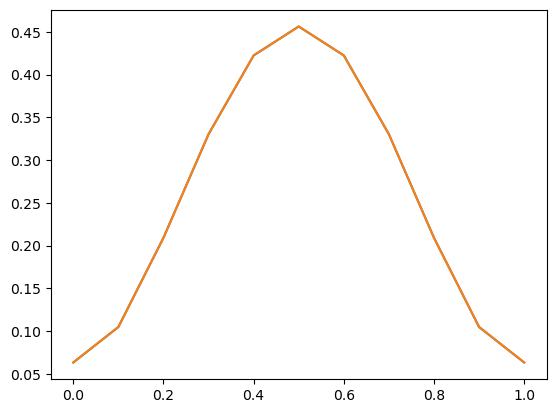

In [17]:
plt.plot(data_obj_dic[11]["linear"].x1, u_clean2[:,5,1])
plt.plot(data_obj_dic[21]["linear"].x1[::2], u_clean1_adj[:,5,1])


MSE between u and u_clean: 2.2060813079305027e-07
ABS between u and u_clean [cells]: 0.015300427530523946
ABS (%) between u and u_clean: 3.2965208805639857e+59


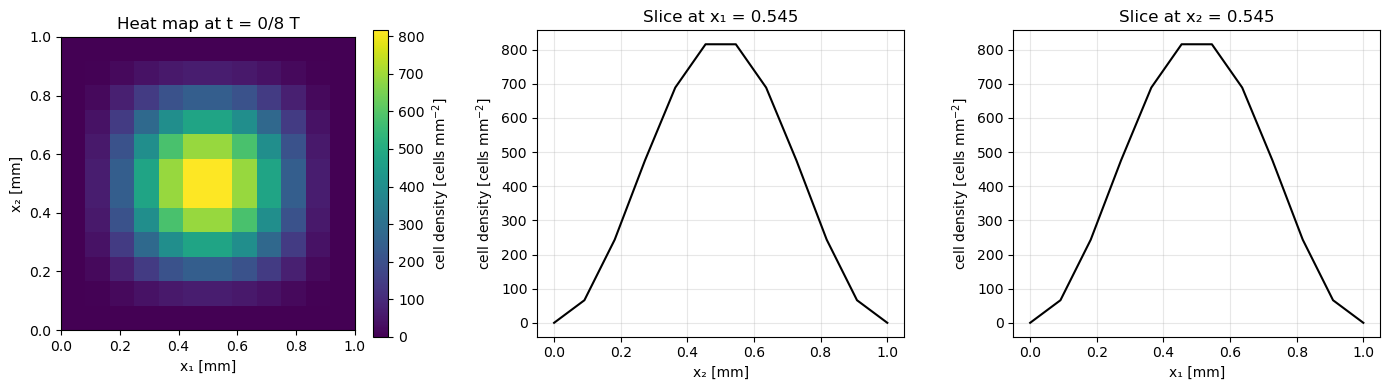

In [ ]:
plot_initial_condition_2d(data_obj)